# 🫁 Chest X-Ray Pneumonia Detection
## Notebook 02 — Model 1: Custom CNN (Built from Scratch)
**Architecture:** 4 Conv Blocks + Dense Layers
**Input Size:** 224 x 224 x 3
**Task:** Binary Classification — NORMAL vs PNEUMONIA

In [2]:
import os, time, json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.utils.class_weight import compute_class_weight
import warnings
warnings.filterwarnings('ignore')

print(f'TensorFlow version: {tf.__version__}')
print(f'GPU Available: {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow version: 2.21.0
GPU Available: False


In [3]:
BASE_DIR = '../data/chest_xray/chest_xray'
TRAIN_DIR  = os.path.join(BASE_DIR, 'train')
VAL_DIR    = os.path.join(BASE_DIR, 'val')
TEST_DIR   = os.path.join(BASE_DIR, 'test')

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
EPOCHS     = 20
LR         = 0.001
MODEL_NAME = 'custom_cnn'

os.makedirs('../models',  exist_ok=True)
os.makedirs('../outputs', exist_ok=True)
print('✅ Config set')

✅ Config set


In [4]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    color_mode='rgb'
)
val_gen = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    color_mode='rgb',
    shuffle=False
)
test_gen = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    color_mode='rgb',
    shuffle=False
)

print(f'Class indices: {train_gen.class_indices}')
print(f'Train samples: {train_gen.samples}')
print(f'Val samples:   {val_gen.samples}')
print(f'Test samples:  {test_gen.samples}')

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}
Train samples: 5216
Val samples:   16
Test samples:  624


In [5]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)
class_weight_dict = dict(enumerate(class_weights))
print(f'Class Weights: {class_weight_dict}')
# NORMAL=0, PNEUMONIA=1

Class Weights: {0: np.float64(1.9448173005219984), 1: np.float64(0.6730322580645162)}


In [6]:
def build_custom_cnn(input_shape=(224, 224, 3)):
    model = models.Sequential([

        # ── Block 1 ──────────────────────────
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.25),

        # ── Block 2 ──────────────────────────
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.25),

        # ── Block 3 ──────────────────────────
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.25),

        # ── Block 4 ──────────────────────────
        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.25),

        # ── Classifier Head ──────────────────
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

model = build_custom_cnn()
model.compile(
    optimizer=tf.keras.optimizers.Adam(LR),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │             

 Total params: 651,169 (2.48 MB)

 Trainable params: 649,697 (2.48 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [7]:
cb_list = [
    callbacks.ModelCheckpoint(
        f'../models/{MODEL_NAME}.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]
print('✅ Callbacks ready')

✅ Callbacks ready


In [8]:
start = time.time()

history = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    class_weight=class_weight_dict,
    callbacks=cb_list
)

train_time = time.time() - start
print(f'\n⏱️  Training Time: {train_time/60:.2f} minutes')

Epoch 1/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.7810 - auc: 0.8938 - loss: 0.4396
Epoch 1: val_accuracy improved from None to 0.50000, saving model to ../models/custom_cnn.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 1272s 8s/step - accuracy: 0.8292 - auc: 0.9243 - loss: 0.3695 - val_accuracy: 0.5000 - val_auc: 0.6875 - val_loss: 1.8164 - learning_rate: 0.0010
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.8851 - auc: 0.9503 - loss: 0.2865
Epoch 2: val_accuracy did not improve from 0.50000
163/163 ━━━━━━━━━━━━━━━━━━━━ 1262s 8s/step - accuracy: 0.8863 - auc: 0.9541 - loss: 0.2755 - val_accuracy: 0.4375 - val_auc: 0.6328 - val_loss: 1.4758 - learning_rate: 0.0010
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.9044 - auc: 0.9692 - loss: 0.2222
Epoch 3: val_accuracy improved from 0.50000 to 0.56250, saving model to ../models/custom_cnn.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 1503s 9s/step - accuracy: 0.9074 - auc: 0.9682 - loss: 0.2260 - val_accuracy: 

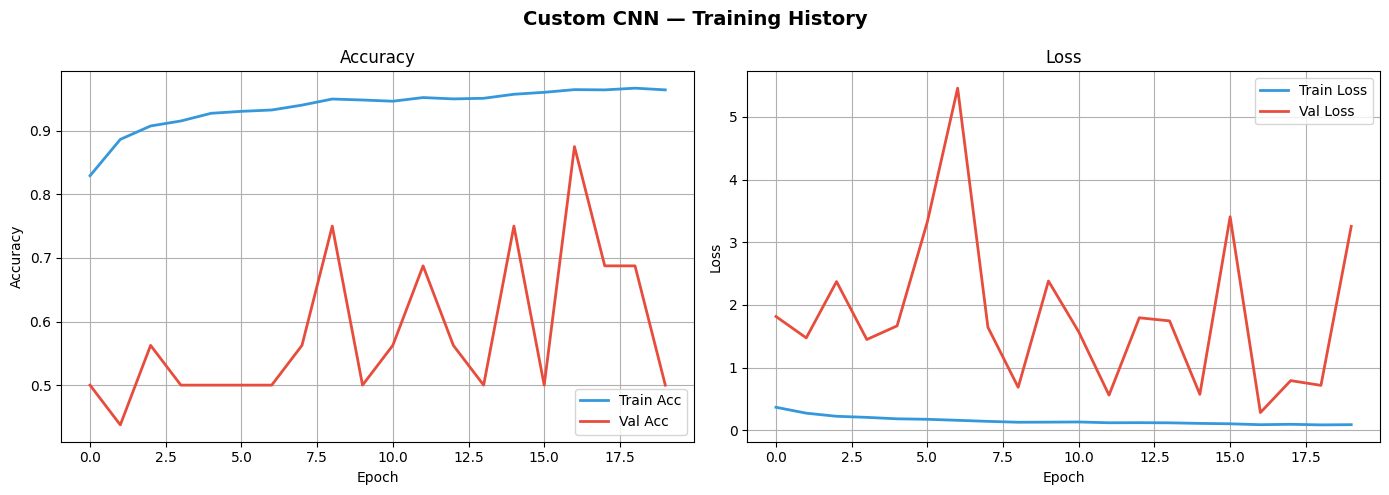

✅ Saved training curves


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Custom CNN — Training History', fontsize=14, fontweight='bold')

axes[0].plot(history.history['accuracy'],     label='Train Acc', color='#3498db', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val Acc',   color='#e74c3c', linewidth=2)
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['loss'],     label='Train Loss', color='#3498db', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val Loss',   color='#e74c3c', linewidth=2)
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(f'../outputs/{MODEL_NAME}_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved training curves')

In [10]:
best_model = tf.keras.models.load_model(f'../models/{MODEL_NAME}.keras')

test_loss, test_acc, test_auc = best_model.evaluate(test_gen, verbose=0)
print(f'Test Accuracy : {test_acc*100:.2f}%')
print(f'Test AUC      : {test_auc:.4f}')
print(f'Test Loss     : {test_loss:.4f}')

y_pred_prob = best_model.predict(test_gen, verbose=0).flatten()
y_pred      = (y_pred_prob >= 0.5).astype(int)
y_true      = test_gen.classes

print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=['NORMAL', 'PNEUMONIA']))

Test Accuracy : 87.34%
Test AUC      : 0.9356
Test Loss     : 0.3371

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.85      0.80      0.83       234
   PNEUMONIA       0.88      0.92      0.90       390

    accuracy                           0.87       624
   macro avg       0.87      0.86      0.86       624
weighted avg       0.87      0.87      0.87       624



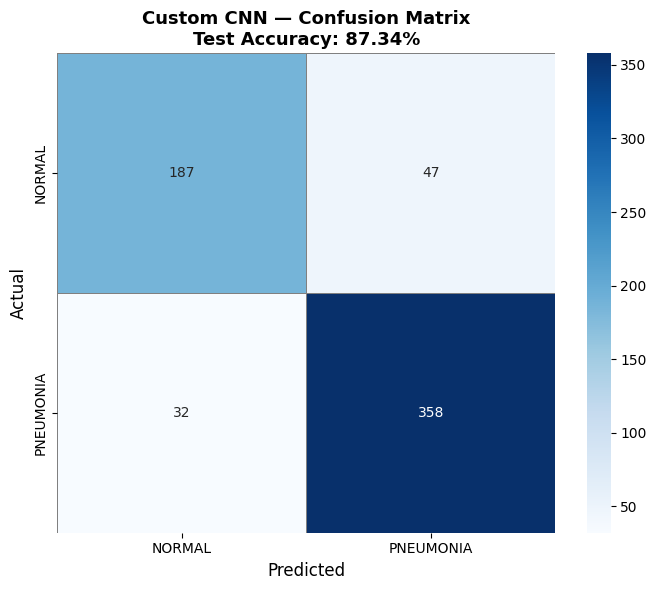

In [11]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['NORMAL', 'PNEUMONIA'],
    yticklabels=['NORMAL', 'PNEUMONIA'],
    linewidths=0.5, linecolor='gray'
)
plt.title(f'Custom CNN — Confusion Matrix\nTest Accuracy: {test_acc*100:.2f}%',
          fontsize=13, fontweight='bold')
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.savefig(f'../outputs/{MODEL_NAME}_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
results = {
    'model':          'Custom CNN',
    'accuracy':       round(test_acc * 100, 2),
    'auc':            round(float(test_auc), 4),
    'precision':      round(precision_score(y_true, y_pred) * 100, 2),
    'recall':         round(recall_score(y_true, y_pred) * 100, 2),
    'f1_score':       round(f1_score(y_true, y_pred) * 100, 2),
    'train_time_min': round(train_time / 60, 2)
}

with open(f'../outputs/{MODEL_NAME}_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print('📦 Results saved!')
print(json.dumps(results, indent=2))
print('\n✅ Next: Notebook 03 — VGG16')

📦 Results saved!
{
  "model": "Custom CNN",
  "accuracy": 87.34,
  "auc": 0.9356,
  "precision": 88.4,
  "recall": 91.79,
  "f1_score": 90.06,
  "train_time_min": 322.02
}

✅ Next: Notebook 03 — VGG16
